In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Keller


In [2]:
@load "combined_dfs.jld2" combined_dfs
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta
@load "mean_traj_keller.jld2" mean_traj

1-element Vector{Symbol}:
 :mean_traj

In [16]:
@save "mean_traj_keller.jld2" mean_traj

In [3]:
function simulate_keller(μ, h, b, D, dt, T, x0)
    # Calculate the effective drift coefficient k_eff from the parabolic gradient
    # ∇c(x) = -2h*x / b^2
    # Drift term = μ * ∇c(x) = - (2 * μ * h / b^2) * x
    k_eff = (2 * μ * h) / (b^2)
    
    nsteps = Int(T / dt)
    x = zeros(nsteps)
    x[1] = x0
    
    for i in 2:nsteps
        ξ = randn()
        # Discrete update: x(t+dt) = x(t) + drift*dt + noise
        # Drift = -k_eff * x(t)

        x[i] = x[i-1] - k_eff * x[i-1] * dt + sqrt(2 * D * dt) * ξ  #Parabola is maximum
        
        # Optional: Handle boundary if distance cannot be negative
        # if x[i] < 0
        #     x[i] = 0.0
        # end
    end
    
    return x
end

simulate_keller (generic function with 1 method)

In [4]:
function run_simulations_and_get_means(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:nrow(dc_delta)
        row = dc_delta[i, :]
        v = row[:v]
        lambda = row[:lambda]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.lambda .== lambda)
        
        k_x = metrics_combined.k_x[mask]
        k_y = metrics_combined.k_y[mask]
        k = mean((k_x + k_y) / 2) * 10   ##AAAAA dt - saved every 10 so dt = 0.1 not 0.01

        sigma_x = metrics_combined.sigma_x[mask]
        sigma_y = metrics_combined.sigma_y[mask]
        sigma = mean((sigma_x + sigma_y) / 2)

        D = sigma^2 * k  #Diffusion coefficient

        h = 1.0          # Peak concentration
        b = l       # Width of the parabola
        μ = (k * b^2) / (2 * h)    # Chemotactic sensitivity   
        dt = 0.01        # Time step
        T = 600.0         # Total time
        x0 = b * 2.5       # Initial position

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_keller(μ, h, b, D, dt, T, x0)
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => x0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means (generic function with 4 methods)

In [6]:
function run_simulations_and_store_trajectories(dc_delta, metrics_combined; n_agents=500, dt=0.01, T=600)
    results = []

    # Filter only rows where v == 10.0
    filtered = dc_delta[dc_delta.v .== 10.0, :]
    filter_2 = filtered[filtered.lambda .== 4.0, :]

    for i in 1:nrow(filter_2)
        row = filter_2[i, :]
        v = row[:v]
        lambda = row[:lambda]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.lambda .== lambda)
        
        k_x = metrics_combined.k_x[mask]
        k_y = metrics_combined.k_y[mask]
        k = mean((k_x + k_y) / 2) * 10   # dt correction

        sigma_x = metrics_combined.sigma_x[mask]
        sigma_y = metrics_combined.sigma_y[mask]
        sigma = mean((sigma_x + sigma_y) / 2)

        D = sigma^2 * k  # Diffusion coefficient

        h = 1.0
        b = l
        μ = (k * b^2) / (2 * h)

        x0 = b * 2.5

        n_steps = Int(T / dt)

        # Store all trajectories (500 agents × time)
        trajectories = Matrix{Float64}(undef, n_agents, n_steps)

        for agent in 1:n_agents
            traj = simulate_keller(μ, h, b, D, dt, T, x0)
            trajectories[agent, :] = traj
        end

        push!(results, Dict(
            :v => v,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => x0,
            :trajectories => trajectories
        ))
    end
   
    return DataFrame(results)
end

run_simulations_and_store_trajectories (generic function with 1 method)

In [ ]:
mean_traj_20 = run_simulations_and_get_means(dc_delta, metrics_combined)

Row,lambda,mean,k,v,D,Dc,delta,r0
,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,0.25,"[158.114, 158.09, 158.071, 158.049, 158.029, 158.008, 157.983, 157.957, 157.942, 157.924 … -0.534517, -0.528928, -0.531306, -0.525523, -0.527073, -0.527883, -0.526394, -0.527854, -0.524009, -0.529922]",0.0138444,5,0.885378,40.0,0.01,158.114
2,0.5,"[79.0569, 79.0357, 79.015, 78.9995, 78.9838, 78.9701, 78.9449, 78.9277, 78.8971, 78.8784 … -0.0671168, -0.0643587, -0.073352, -0.0786051, -0.0689878, -0.063994, -0.0606449, -0.0647663, -0.0594285, -0.061153]",0.0249453,5,1.06297,20.0,0.02,79.0569
3,0.75,"[52.698, 52.681, 52.6634, 52.6379, 52.6254, 52.5987, 52.5849, 52.5727, 52.5595, 52.5467 … 0.151614, 0.148935, 0.147894, 0.141999, 0.145169, 0.152297, 0.144956, 0.145377, 0.138633, 0.143032]",0.0321178,5,1.18981,13.33,0.03,52.698
4,1.0,"[39.5285, 39.5224, 39.5004, 39.4864, 39.4776, 39.4659, 39.449, 39.4319, 39.4104, 39.4008 … -0.212032, -0.215481, -0.216085, -0.215549, -0.21436, -0.220991, -0.21442, -0.226412, -0.218902, -0.221119]",0.0357539,5,1.27819,10.0,0.04,39.5285
5,2.0,"[19.7642, 19.755, 19.7533, 19.7544, 19.7401, 19.7332, 19.726, 19.716, 19.7112, 19.7066 … 0.399135, 0.406619, 0.408194, 0.408985, 0.407376, 0.406278, 0.416794, 0.422414, 0.419706, 0.410736]",0.0385313,5,1.54134,5.0,0.08,19.7642
6,3.0,"[13.1762, 13.1669, 13.1542, 13.1461, 13.143, 13.1379, 13.1179, 13.0994, 13.0909, 13.0791 … 0.0827012, 0.0892962, 0.0789012, 0.0702399, 0.0662963, 0.0729313, 0.0703831, 0.0650219, 0.0684603, 0.0678808]",0.0365666,5,1.50754,3.33333,0.12,13.1762
7,4.0,"[9.88212, 9.87514, 9.86611, 9.86798, 9.85849, 9.85168, 9.8378, 9.83211, 9.82387, 9.81728 … 0.000981559, -0.00610527, -0.0134704, -0.0106638, -0.0145147, -0.0118447, -0.0140667, -0.0151711, -0.00616777, -0.00366829]",0.0363378,5,1.4033,2.5,0.16,9.88212
8,5.0,"[7.90569, 7.90371, 7.89493, 7.89201, 7.88317, 7.87998, 7.88473, 7.87861, 7.88246, 7.87707 … 0.0847895, 0.0950805, 0.0799206, 0.0924321, 0.0921116, 0.0926168, 0.0887347, 0.0746672, 0.082753, 0.0774237]",0.0378552,5,1.82536,2.0,0.2,7.90569
9,6.0,"[6.58808, 6.59021, 6.58729, 6.57407, 6.58125, 6.57246, 6.56807, 6.56007, 6.55821, 6.55949 … 0.0507318, 0.0485796, 0.045214, 0.0519128, 0.0500004, 0.0535702, 0.0430104, 0.0448321, 0.0468405, 0.0400369]",0.0383565,5,2.34556,1.66667,0.24,6.58808


In [7]:
mean_traj_10_4 = run_simulations_and_store_trajectories(dc_delta, metrics_combined)

Row,lambda,k,v,D,Dc,trajectories,delta,r0
,Float64,Float64,Int64,Float64,Float64,Array…,Float64,Float64
1,4.0,0.0600384,10,4.12297,2.5,[19.7642 19.4911 … -3.30281 -3.43921; 19.7642 19.8038 … 6.78708 6.88426; … ; 19.7642 19.7392 … 5.15078 5.28663; 19.7642 19.3986 … 12.1482 12.4306],0.04,19.7642


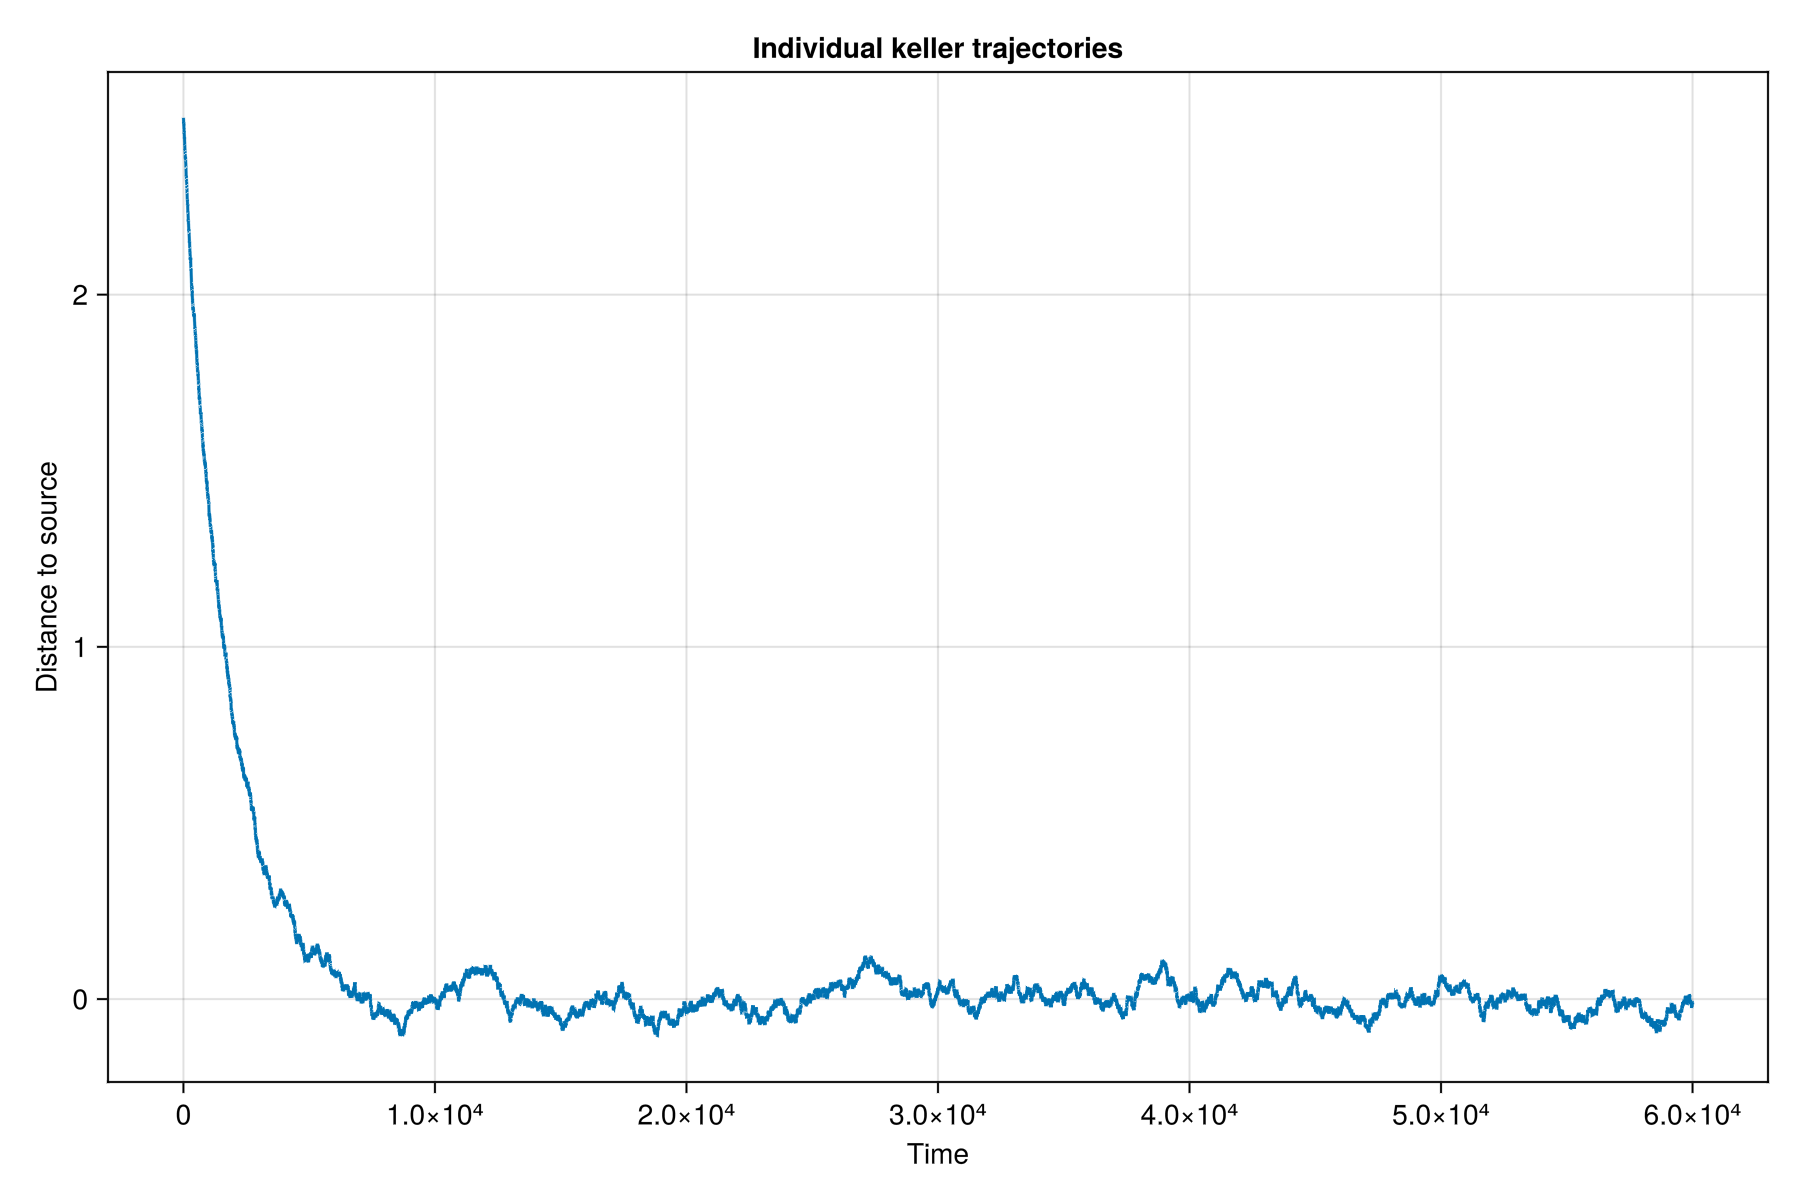

In [9]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Individual keller trajectories", xlabel = "Time", ylabel = "Distance to source")

# mask = (mean_traj_10_4.lambda .== 4.0)
matrix = mean_traj_10_4.trajectories
mat = matrix[1]
mean_traj = Float64[]
for i in 1:60000
    traj = mat[:, i]
    norm = traj ./ 7.9
    push!(mean_traj, mean(norm)) 
end
# for i in 1:3
#     traj = mat[i, :]
#     lines!(ax, 1:60000, traj)
# end
lines!(ax, 1:60000, mean_traj)
fig

In [ ]:
function run_simulations_and_get_means(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:nrow(dc_delta)
        row = dc_delta[i, :]
        v = row[:v]
        lambda = row[:lambda]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.lambda .== lambda)
        
        k_x = metrics_combined.k_x[mask]
        k_y = metrics_combined.k_y[mask]
        k = mean((k_x + k_y) / 2) * 10   ##AAAAA dt - saved every 10 so dt = 0.1 not 0.01

        sigma_x = metrics_combined.sigma_x[mask]
        sigma_y = metrics_combined.sigma_y[mask]
        sigma = mean((sigma_x + sigma_y) / 2)

        D = sigma^2 * k  #Diffusion coefficient

        h = 1.0          # Peak concentration
        b = l       # Width of the parabola
        μ = (k * b^2) / (2 * h)    # Chemotactic sensitivity   
        dt = 0.01        # Time step
        T = 600.0         # Total time
        x0 = b * 2.5       # Initial position

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_keller(μ, h, b, D, dt, T, x0)
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => x0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means (generic function with 4 methods)

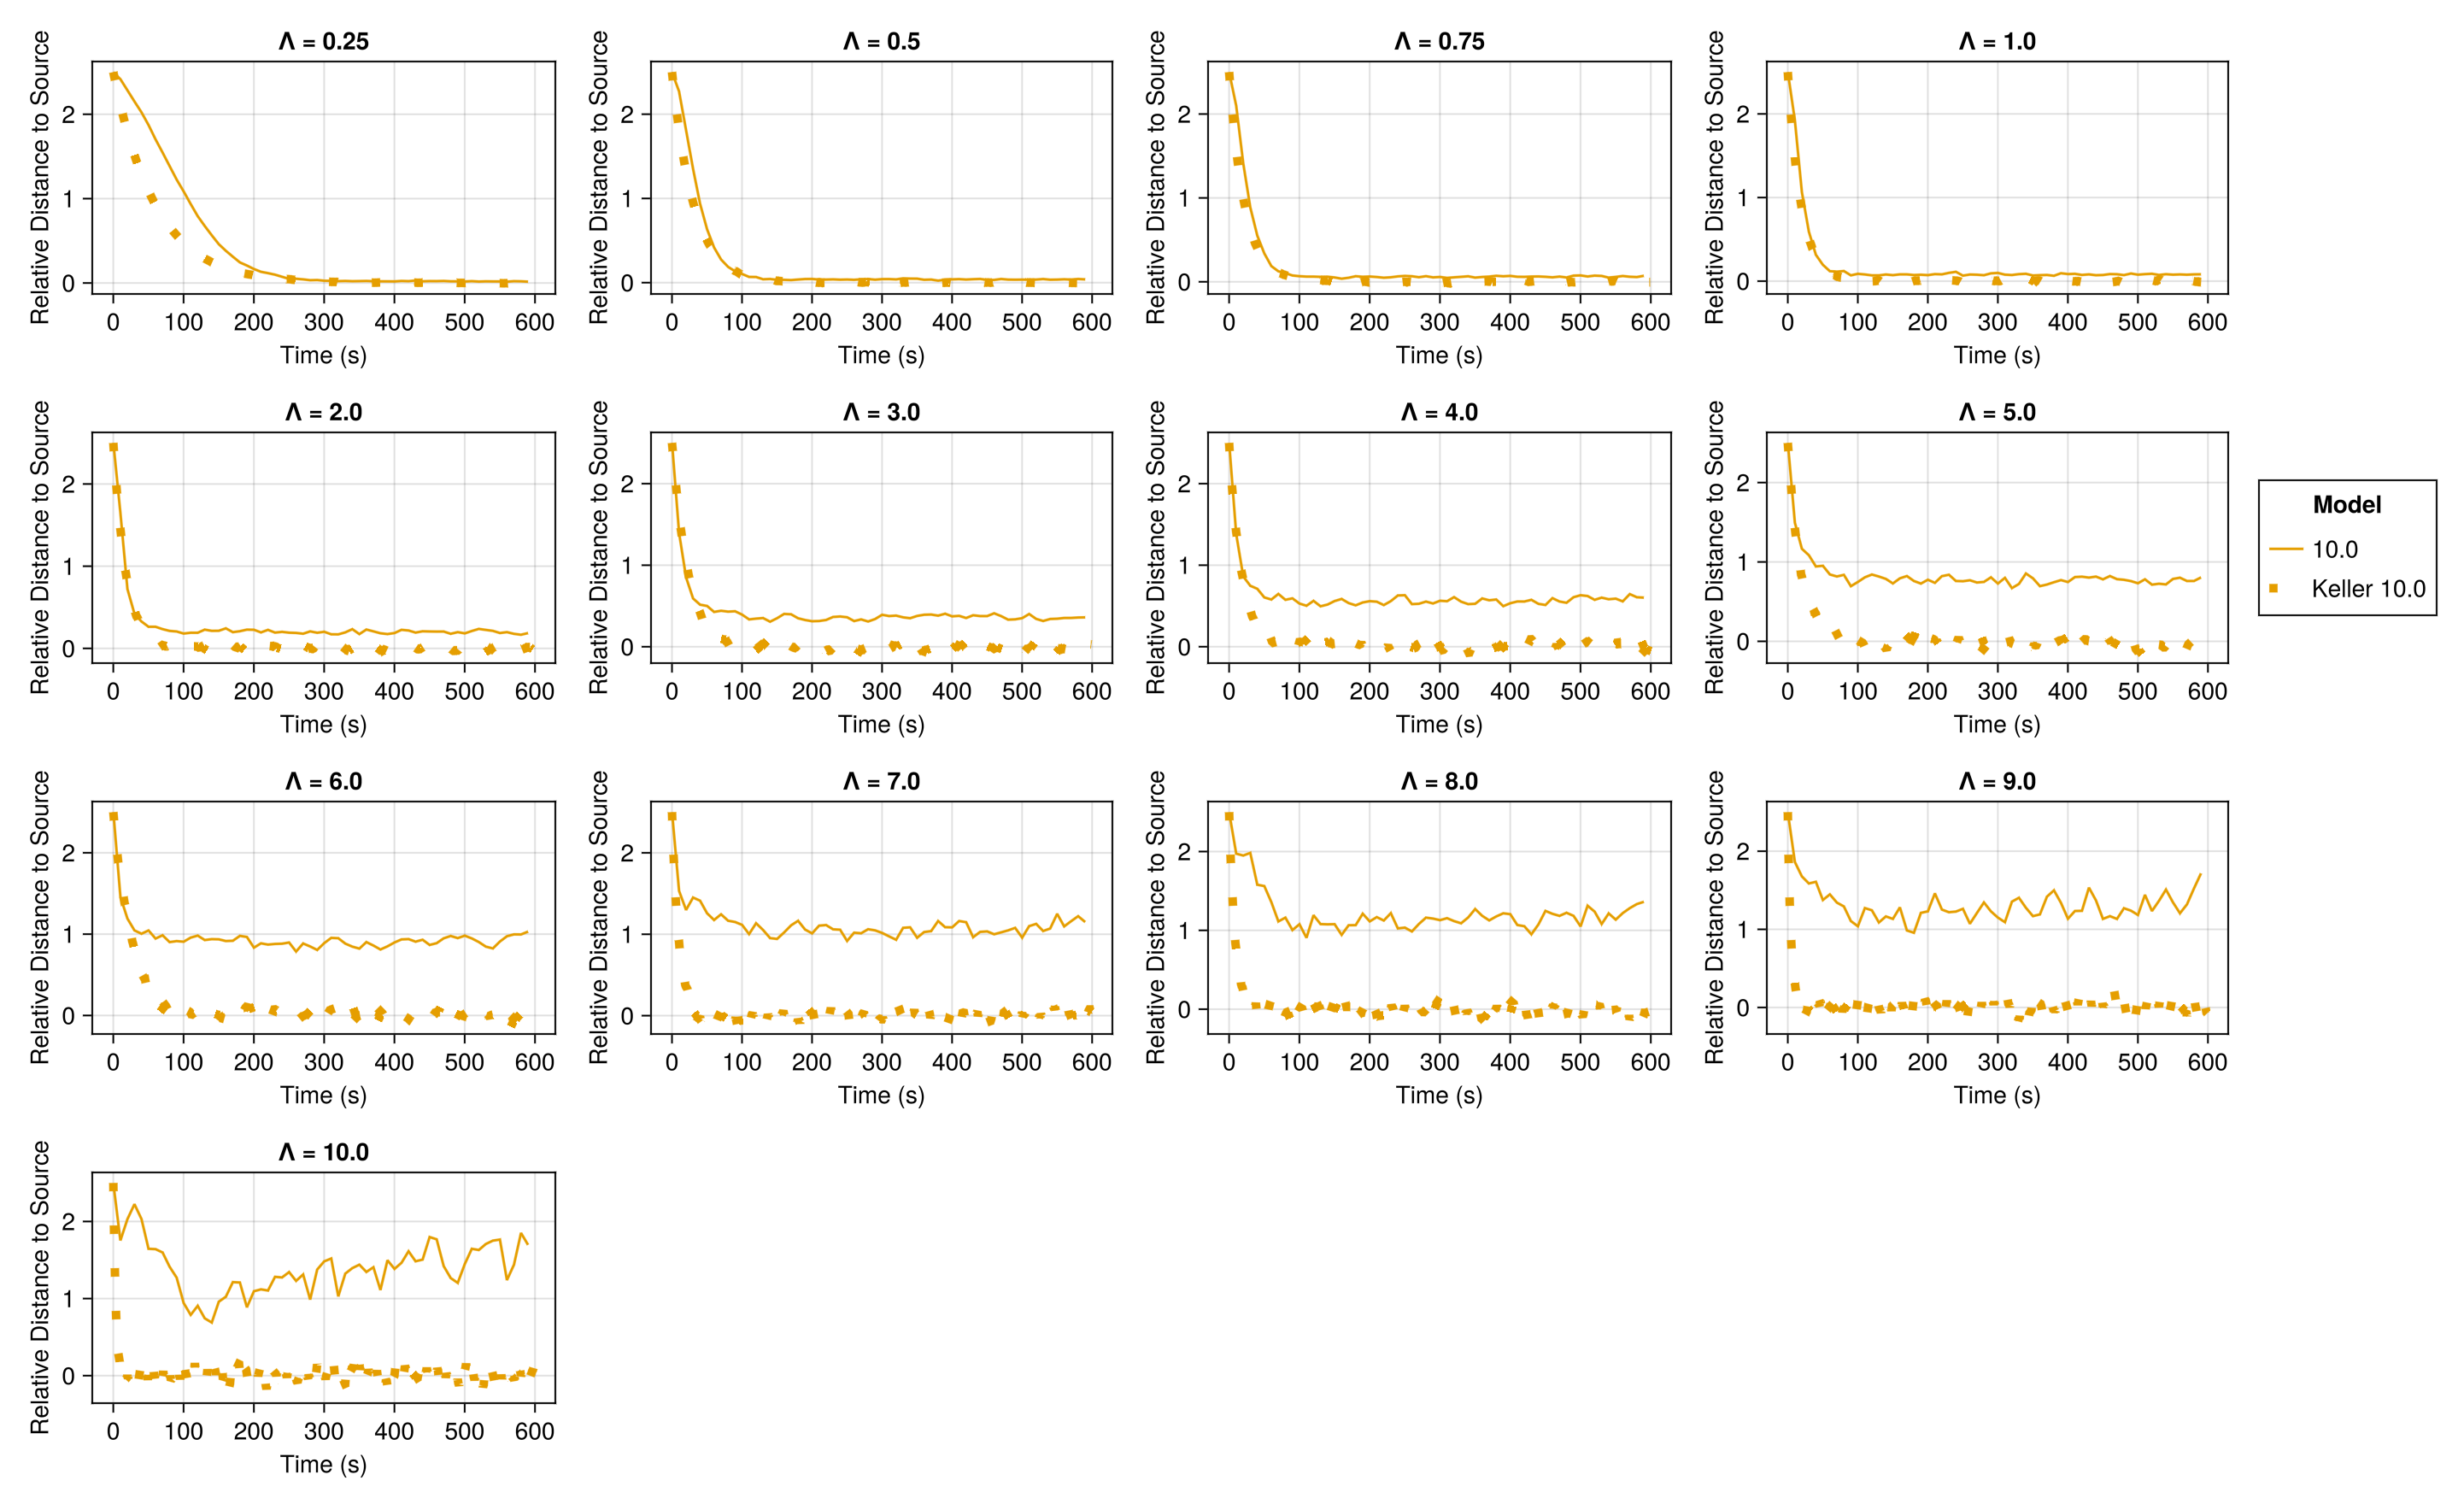

GLMakie.Screen(...)

In [14]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

# velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
# thresholds = [40, 75, 275, 850]
# thresholds = [40]
thresholds = [75]
# thresholds = [275]
# thresholds = [850]
# colors = [:red, :blue, :green, :yellow]
# colors_2 = [:pink, :black, :brown, :orange]
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [RGBf(0.90, 0.62, 0.0)]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = combined_dfs[(v, lambda)]

        color = colors[v_idx]
        # color_2 = colors_2[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        eq = grouped[3000:end]
        df_subset = DataFrame(eq)

        if lambda < 6.0

            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        else
            t = (thresholds[v_idx])/2
            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        end

        bad_agents = unique(df_subset[bad_rows_mask, :agent])

        df_clean = filter(row -> !(row.agent in bad_agents), df)

        if isempty(df_clean)
            @warn "No data for v=$v, lambda=$lambda. Skipping."
            continue
        end

        grouped_t = groupby(df_clean, :step)
        
        if isempty(grouped_t)
             @warn "No steps found in filtered data."
             continue
        end


        for i in 1:100:length(grouped_t)
            data_1 = grouped_t[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj.lambda .== lambda) .& (mean_traj.v .== v) 

        mean_OU = mean_traj.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        
        lines!(ax_x, (1:100:length(grouped_t))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "Keller $v")


        if idx == 13 & v_idx == 1
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [15]:
save("Plots/Fixed_source_model/Keller/Keller_only_v10_2.png", fig2)

In [20]:
@save "mean_traj_keller.jld2" mean_traj

In [ ]:
fig3 = Figure(size=(1200, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Distance X")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Distance Y")



steps = 60000

jldopen("fsb_10.0_lambda_0.25.jld2", "r") do file 
    for agent in 2:100
        x = Float64[] 
        y = Float64[]

        for step in 1:10:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = 0
            ys = 0

            x_1 = g["x"][agent]
            y_1 = g["y"][agent]

            # dist = abs(sqrt((x_1 - xs)^2 + (y_1 - ys)^2))
            dist = x_1 - xs
            dist_2 = y_1 - ys

            push!(x, dist)
            push!(y, dist_2)
    

        end

        # lines!(ax1, 1:steps, log.(x))
        lines!(ax1, 1:10:steps, x)
        lines!(ax2, 1:10:steps, y)
        
    end

end
display(fig3)

# Bessel derivative

In [13]:
function simulate_keller_bessel(k, l, D, dt, T, x0)
    """
    Simulate agent trajectories using a Bessel field (K_0) as the chemical gradient.
    
    Parameters:
    - k: The target force constant (from your OU process constraint: Force = k * x).
    - l: The length scale of the Bessel field.
    - D: Diffusion coefficient.
    - dt: Time step.
    - T: Total simulation time.
    - x0: Initial position (vector, e.g., [x, y] for 2D).
    
    Returns:
    - traj: Matrix of trajectories (2 x N steps) for 2D, or Vector for 1D.
    """
    
    # Initial setup
    dim = length(x0)
    nsteps = Int(T / dt)
    traj = zeros(dim, nsteps)
    traj[:, 1] .= x0
    Z_THRESHOLD = 50.0 
    # Pre-allocate random noise if needed, or generate on the fly
    # Using randn() inside the loop is fine for this size
    
    for i in 2:nsteps
        x_curr = traj[:, i-1]
        r = norm(x_curr) # Scalar distance from source (0,0)
        z = r/l
        if z > Z_THRESHOLD
            # Asymptotic approximation for K_1(z)
            # K_1(z) ~ sqrt(pi/(2z)) * exp(-z) * (1 + 3/(8z))
            sqrt_term = sqrt(pi / (2 * z))
            exp_term = exp(-z)
            K1_val = sqrt_term * exp_term * (1.0 + 3.0 / (8.0 * z))
        elseif z < 1e-10
            # Near zero: K_1(z) ~ 1/z
            # This handles the singularity at r=0
            K1_val = 1.0 / z
        else
            # Standard calculation for moderate z
            K1_val = besselk(1, z)
        end
        # 1. Calculate mu based on the constraint: mu * grad_c = k * x
        # Formula: mu = - (k * l * r) / K_1(r/l)
        # We add a small epsilon to r to avoid division by zero if x=0
        if z < 1e-10
            mu = 0.0
        else
            # K_1 is the modified Bessel function of the second kind, order 1
            mu = - (k * l * r) / K1_val
        end
        println("here", i)
        scalar_deriv = -1.0/l * K1_val
        grad_vec = (scalar_deriv / r) * x_curr # Vector pointing towards/away from source

        # Drift = mu * grad_vec
        drift = mu * grad_vec
        
        # 3. Calculate Noise
        noise = sqrt(2 * D * dt) .* randn(dim)
        
        # 4. Euler-Maruyama Update
        x_next = x_curr + drift * dt + noise
        
        # # Optional: Handle boundary (if your model requires non-negative distances or walls)
        # # If x represents distance in 1D and cannot be negative:
        # if dim == 1 && x_next[1] < 0
        #     x_next[1] = 0.0 # Reflect or clamp
        # end
        
        traj[:, i] = x_next
    end
    
    return traj
end

simulate_keller_bessel (generic function with 1 method)

In [ ]:
function run_simulations_and_get_means_bessel(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:2
        row = dc_delta[i, :]
        v = row[:v]
        lambda = row[:lambda]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        x0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.lambda .== lambda)
        
        k_x = metrics_combined.k_x[mask]
        k_y = metrics_combined.k_y[mask]
        k = mean((k_x + k_y) / 2) * 10   ##AAAAA dt - saved every 10 so dt = 0.1 not 0.01

        sigma_x = metrics_combined.sigma_x[mask]
        sigma_y = metrics_combined.sigma_y[mask]
        sigma = mean((sigma_x + sigma_y) / 2)

        D = sigma^2 * k  #Diffusion coefficient

       # Initial position

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_keller_bessel(k, l, D, dt, T, x0)
            
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => x0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means_bessel (generic function with 4 methods)

In [18]:
bessel_mean_traj = run_simulations_and_get_means_bessel(dc_delta, metrics_combined)

DimensionMismatch: DimensionMismatch: cannot broadcast array to have fewer non-singleton dimensions

# Plot without separated subpopulations

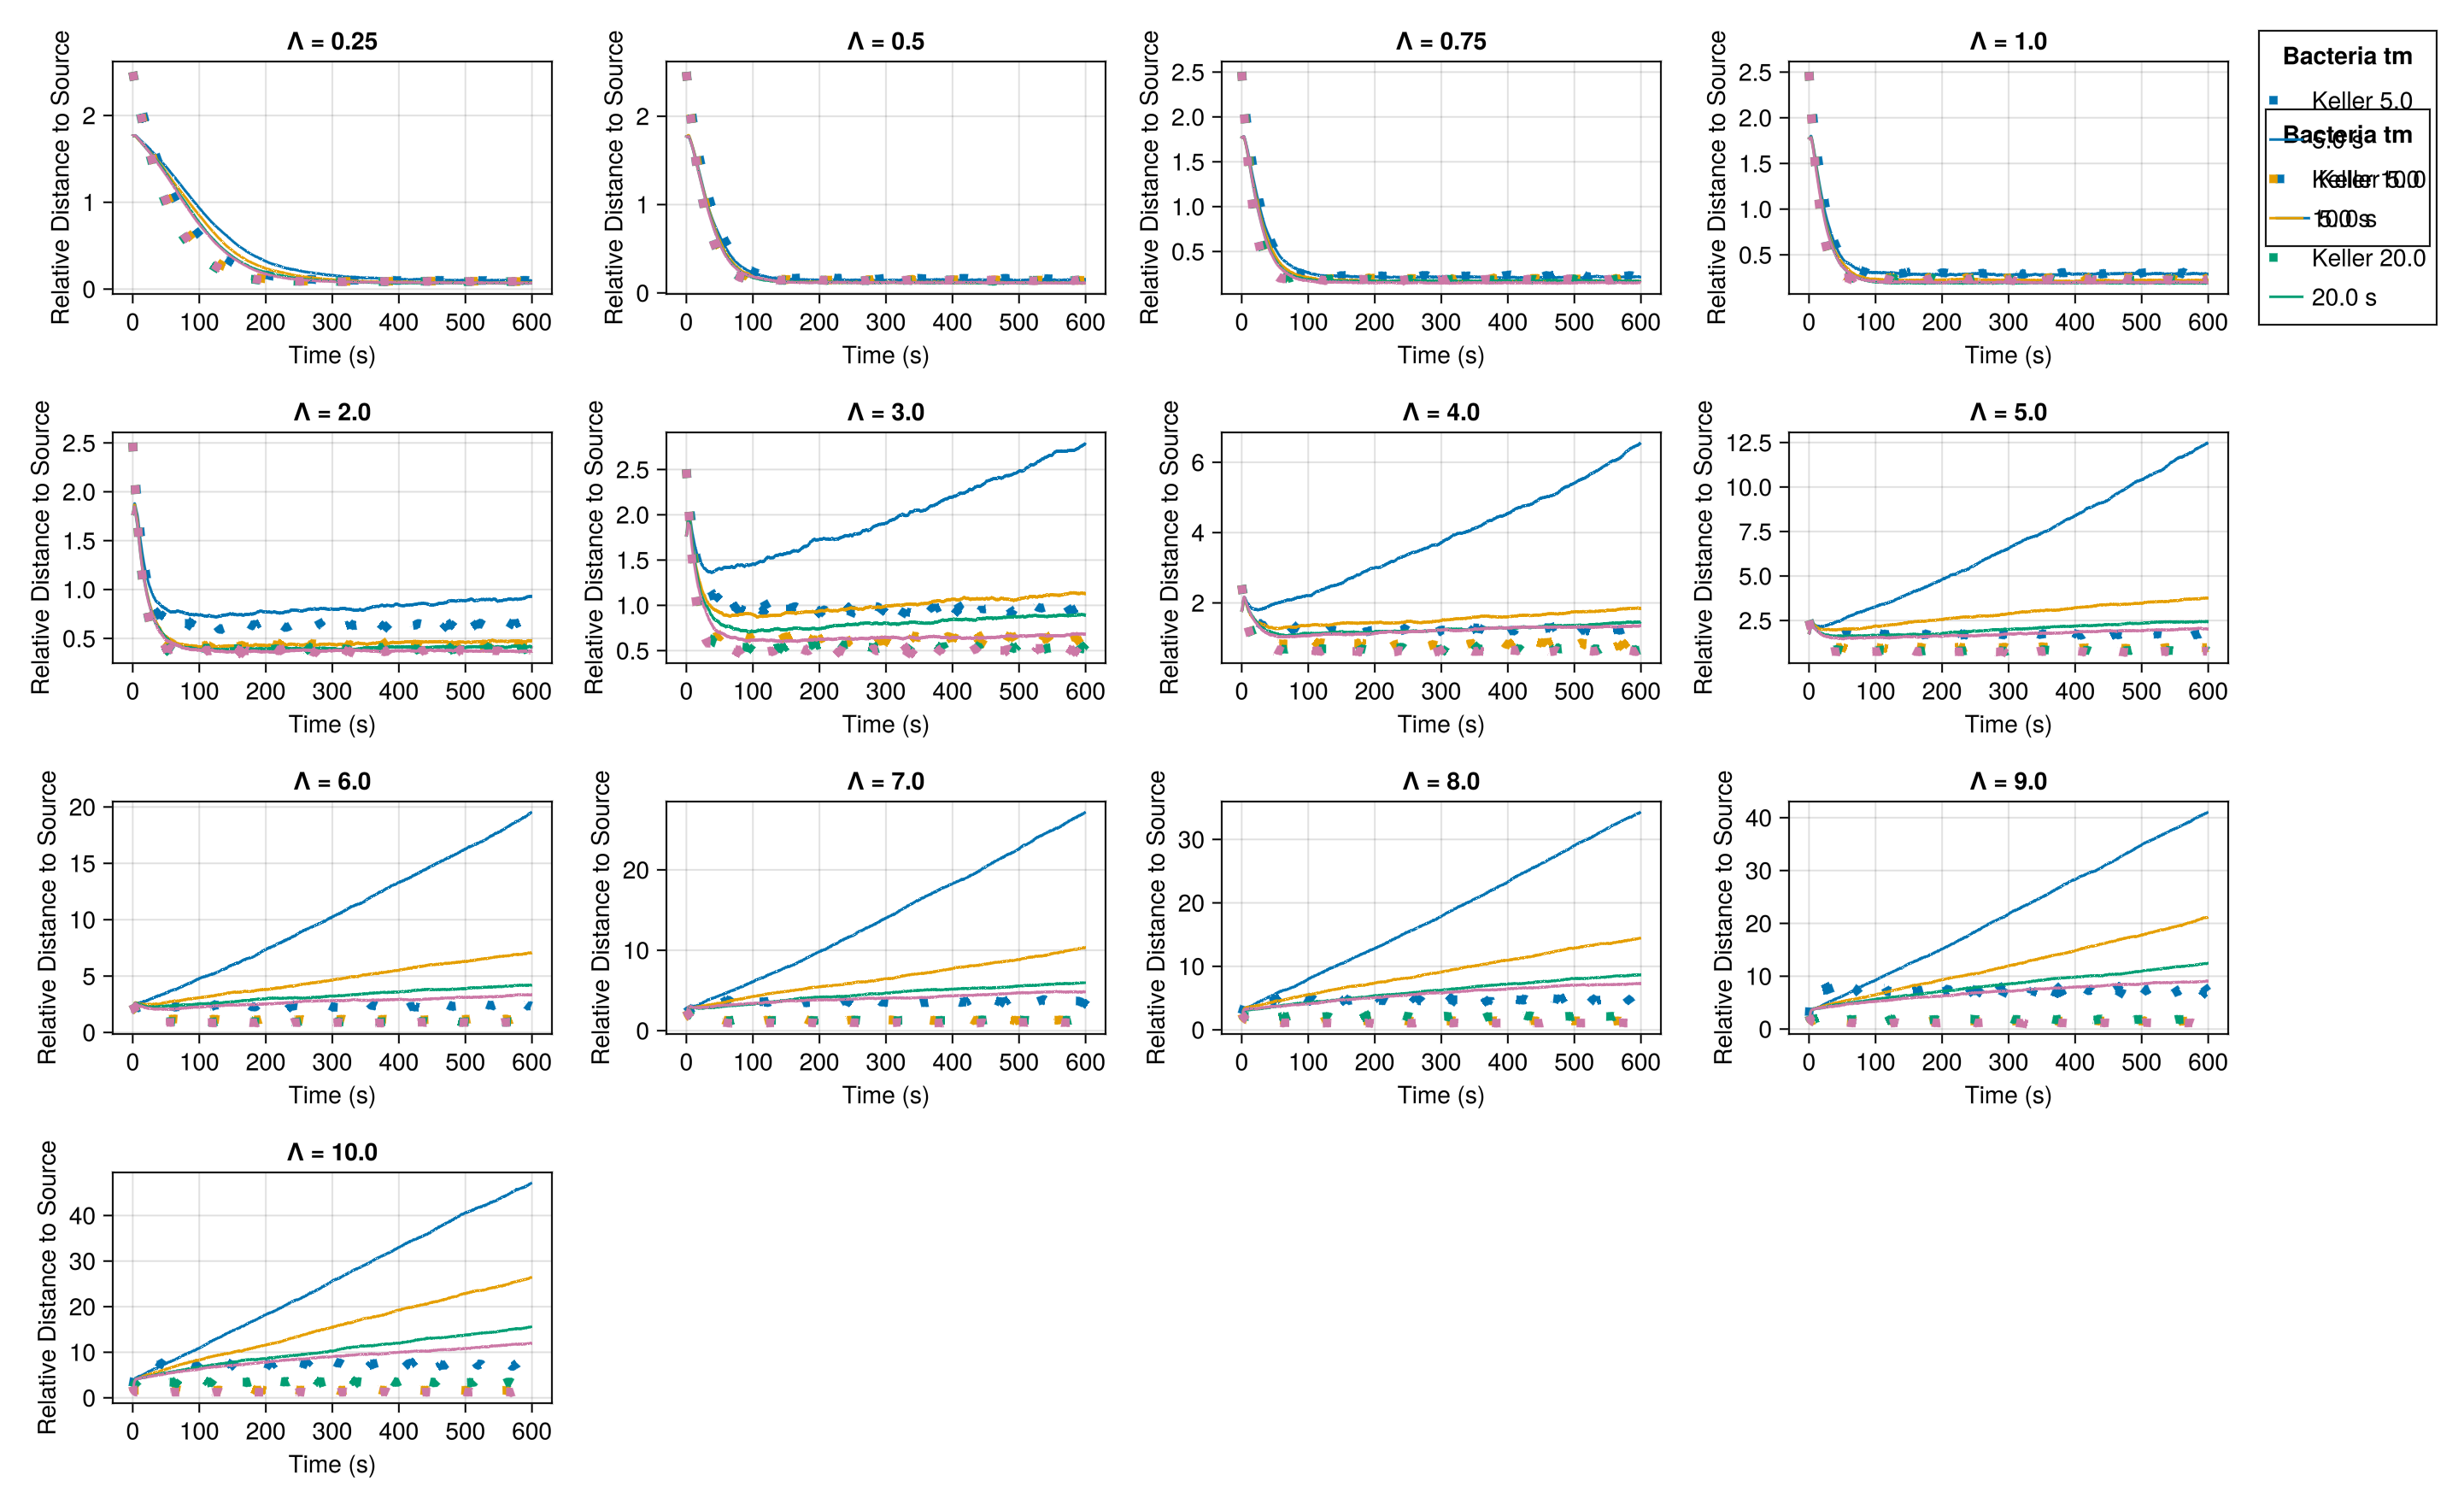

GLMakie.Screen(...)

In [3]:
# Define the lambda values to iterate over
# lambdas = [0.25]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

# Define the velocities to test
# adaptations = [2.0]
velocities = [5.0, 10.0, 20.0, 100.0]
colors = [
    RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    RGBf(0.0, 0.62, 0.45),   # green
    RGBf(0.80, 0.47, 0.65)   # magenta
]
# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig3 = Figure(size=(900 * cols, 600 * rows))

# Loop through each lambda value FIRST (creates the grid)
for (idx, lambda) in enumerate(lambdas)
    # Determine grid position
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax = Axis(fig3[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")
    

    # Loop through each velocity to plot on the SAME axis
    for (v_idx, v) in enumerate(velocities)
        color = colors[v_idx]
        
        try
            # Filename format: fsb_{v}_lambda_{lambda}.jld2
            filename = @sprintf("fsb_%s_lambda_%s.jld2", v, lambda)
        
            jldopen(filename, "r") do file 
                raw_dist_x = Float64[]

                meta_data = file["meta"]
                Dc = meta_data["DMedium"]
                delta = meta_data["delta"]
                l = sqrt(Dc/delta)
                
                for step in 1:steps
                    g = file[@sprintf("step_%06d", step)]
                    # Ensure com.N is defined globally

                    other_x = g["x"]
                    other_y = g["y"]

                    dx = other_x .- 0
                    dy = other_y .- 0
                    
                    dists_r = sqrt.(dx.^2 .+ dy.^2)
                    norm = dists_r ./ l

                    push!(raw_dist_x, mean(norm))
            
                end
                mask = (mean_traj.lambda .== lambda) .& (mean_traj.v .== v) 

                mean_OU = mean_traj.mean[mask]
                mean_OUl = mean_OU ./ l 
                flat_vec = vcat(mean_OUl...)
                idx_l = 1:100:length(flat_vec)
                

                lines!(ax, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "Keller $v")
                
                # Plot the normalized line
                lines!(ax, (1:steps)*0.01, raw_dist_x, color = color, label="$v s")
        
                # Plot the error band for the normalized data
                # band!(ax, (1:steps)*0.01, normalized_dist_x .- sem_norm, normalized_dist_x .+ sem_norm, 
                #       color=(color, 0.2), label = "") 
            end
            if idx == 1 & v_idx == 1
                leg = Legend(fig3[:,5], ax, "Bacteria tm")
            end

        catch e
            @warn "Could not load file for lambda $lambda, tm=$v: $e"
        end
        
    end
end

display(fig3)

In [4]:
save("Plots/Fixed_source_model/Keller/no_separat.png", fig3)

# Double well parabola

In [ ]:
function simulate_keller(μ, b, D, dt, T, x0)
    # Calculate the effective drift coefficient k_eff from the parabolic gradient
    # ∇c(x) = -2h*x / b^2
    # Drift term = μ * ∇c(x) = - (2 * μ * h / b^2) * x
    k_eff = (4 * μ) / (b^4)
    
    nsteps = Int(T / dt)
    x = zeros(nsteps)
    x[1] = x0
    
    for i in 2:nsteps
        ξ = randn()
        # Discrete update: x(t+dt) = x(t) + drift*dt + noise
        # Drift = -k_eff * x(t)
        x[i] = x[i-1] - k_eff * x[i-1] * dt + sqrt(2 * D * dt) * ξ  #Parabola is maximum
        
        # Optional: Handle boundary if distance cannot be negative
        if x[i] < 0
            x[i] = 0.0
        end
    end
    
    return x
end

simulate_keller (generic function with 2 methods)

In [6]:
df = combined_dfs[(10.0, 1.0)]
metrics_combined

Row,v,lambda,mu_x,mu_y,sigma_x,sigma_y,k_x,k_y
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,20.0,4.0,4.12085,4.20449,13.8417,13.6265,0.00504218,0.00547748
2,100.0,9.0,8.39487,8.52574,52.4909,52.2096,0.0157368,0.0124633
3,5.0,9.0,0.546728,1.73051,17.1098,16.3216,0.0185338,0.0214704
4,20.0,9.0,4.49154,3.80964,13.0998,20.0125,0.0180716,0.0235423
5,100.0,5.0,8.19036,8.64306,60.1512,60.0034,0.00745649,0.00661533
6,5.0,5.0,4.86336,4.82832,7.05832,6.82974,0.00404968,0.00352136
7,20.0,5.0,4.63605,4.33942,13.2483,13.1891,0.00577897,0.00578884
8,100.0,6.0,8.65329,8.52334,57.7068,57.7475,0.00568984,0.00644998
9,5.0,6.0,4.67125,4.67106,8.08399,7.55588,0.00340852,0.00426279


In [ ]:
b = 31
mask_m = (metrics_combined.v .== 10.0) .& (metrics_combined.lambda .== 1.0) 
k = mean(((metrics_combined.k_x[mask_m] .- metrics_combined.k_y[mask_m]) ./2) .*10)
sigma = mean(((metrics_combined.sigma_x[mask_m] .- metrics_combined.sigma_y[mask_m]) ./2))

D = sigma .^2 .* k
μ = (k * b^4) / (4)    # Chemotactic sensitivity   
dt = 0.01        # Time step
T = 600.0         # Total time
x0 = b * 2.5       # Initial position

trajectory = simulate_keller(μ, b, D, dt, T, x0)

60000-element Vector{Float64}:
 77.5
 77.49765269360566
 77.49542747487037
 77.49290319996793
 77.4904506426333
 77.4880108451487
 77.48573402746744
 77.48339154393993
 77.48116738333486
 77.47894285564881
  ⋮
 12.37609295494736
 12.375824640931837
 12.375309303039318
 12.37526821598324
 12.375109223239862
 12.374688872017536
 12.374669487217458
 12.374481059231465
 12.37414680044779

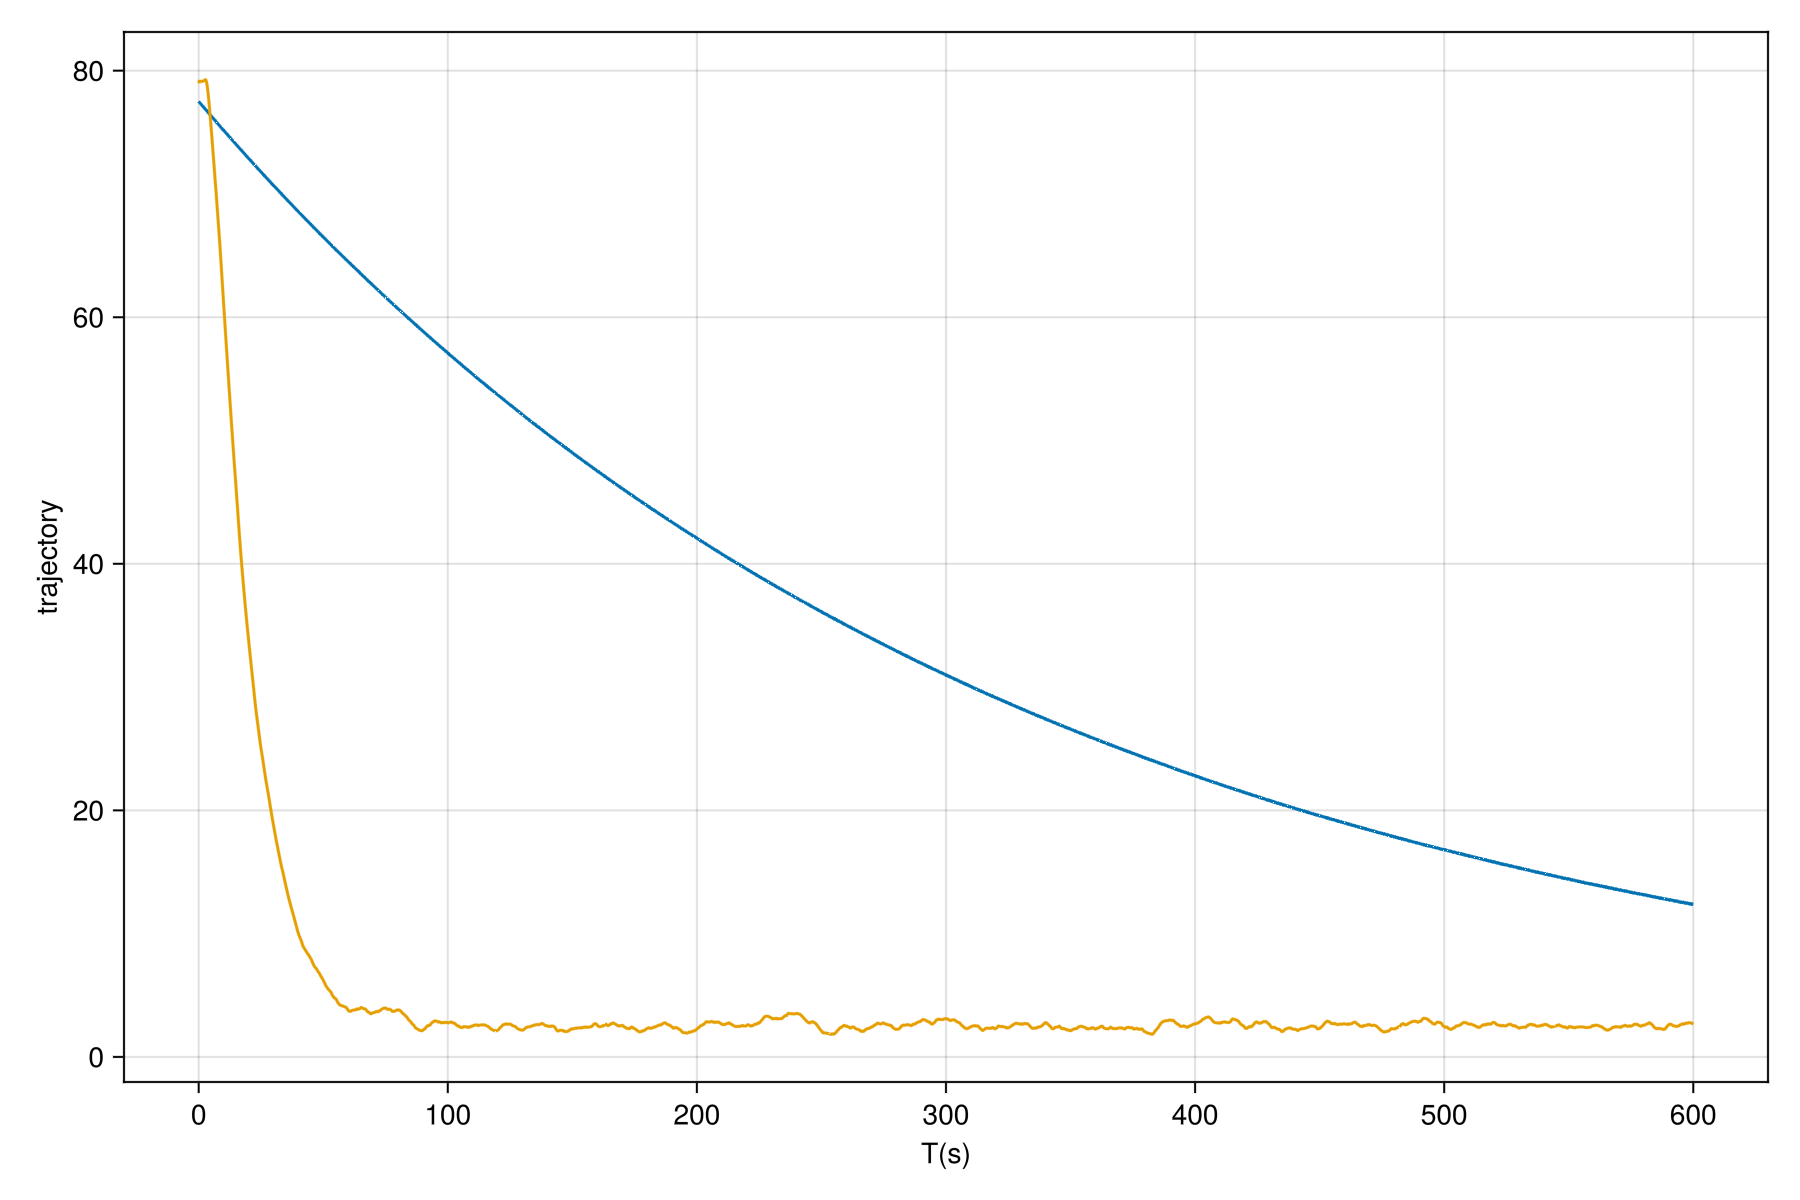

In [13]:
fig = Figure(size = (900, 600))
ax = Axis(fig[1,1], xlabel = "T(s)", ylabel = "trajectory")

steps = T / dt
grouped = groupby(df, :step)
mean_x = Float64[]
for i in 1:length(grouped)
    step_df = grouped[i]
    x = step_df.x
    push!(mean_x, mean(x))
end

steps_2 = 6000
lines!(ax, (1:steps)*0.01, trajectory)
lines!(ax, (1:steps_2)*0.1, mean_x)
fig

In [13]:
save("Plots/Fixed_source_model/keller_l05_v10_two_min.png", fig)

# Individual trajectories

In [23]:
combined_dfs[(10.0, 1.0)]

Row,step,agent,x,y
,Int64,Int64,Float64,Float64
1,1,1,0.0,0.0
2,11,1,0.0,0.0
3,21,1,0.0,0.0
4,31,1,0.0,0.0
5,41,1,0.0,0.0
6,51,1,0.0,0.0
7,61,1,0.0,0.0
8,71,1,0.0,0.0
9,81,1,0.0,0.0


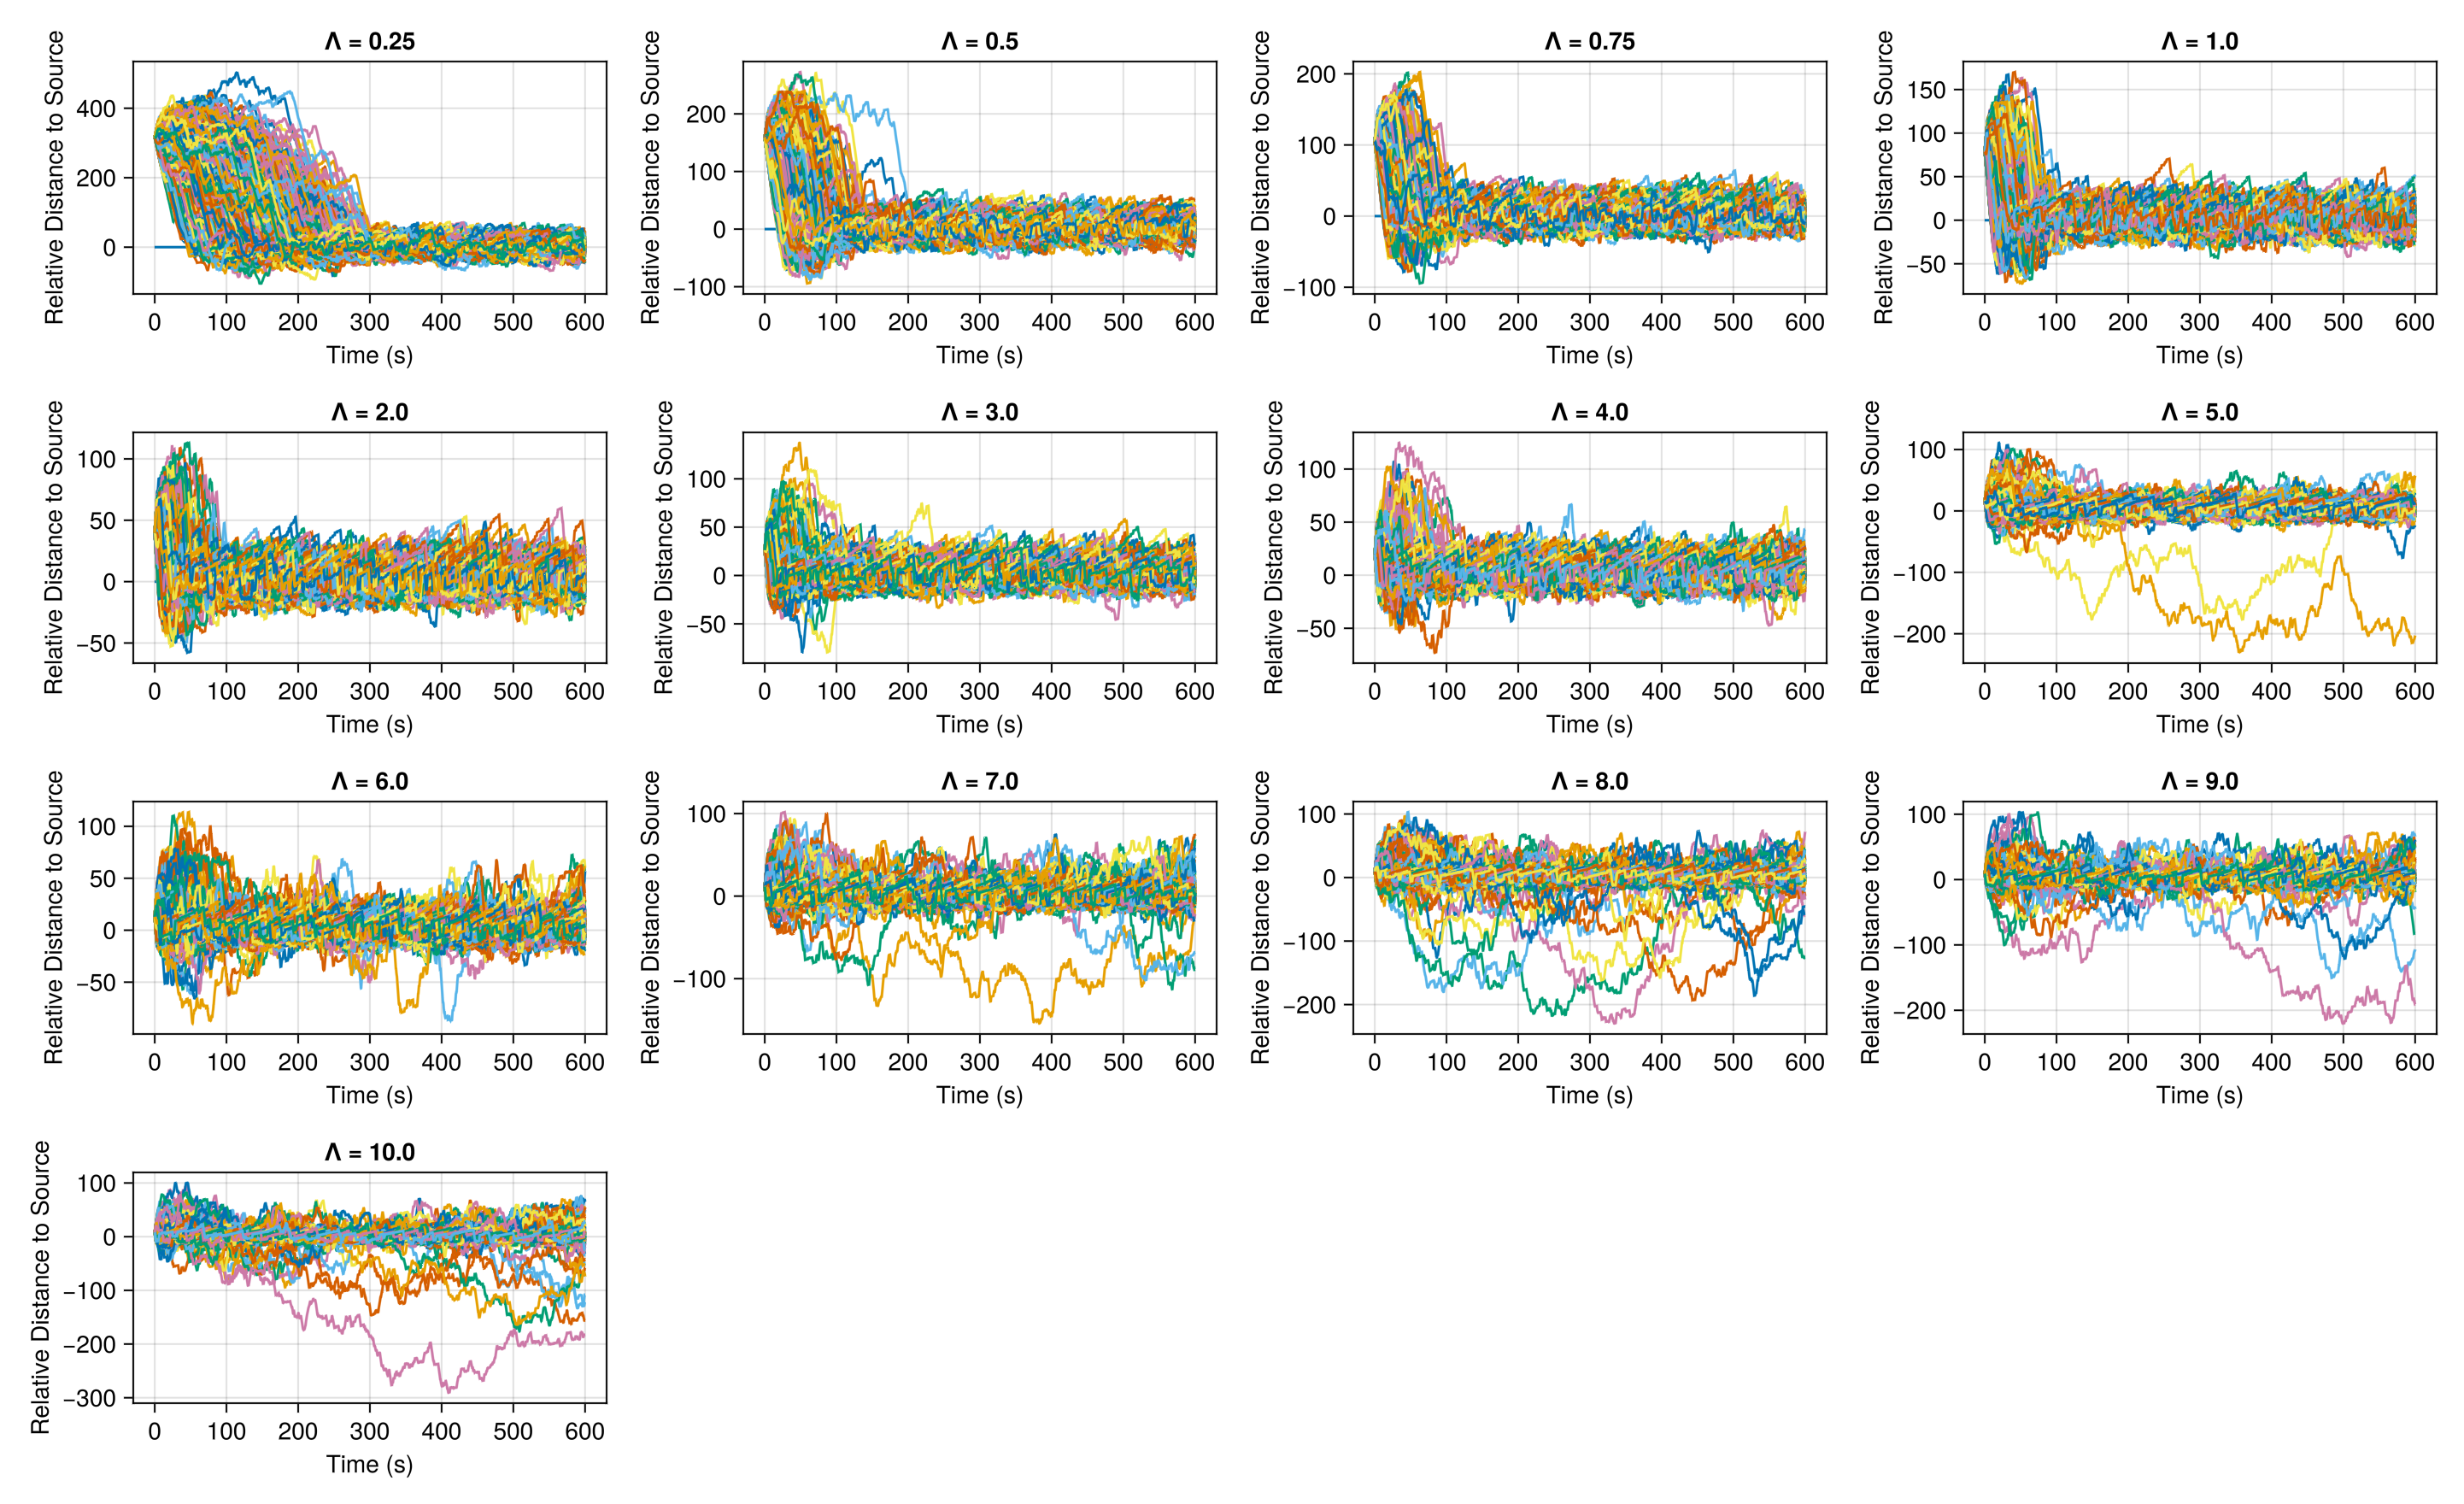

In [28]:
combined_dfs
velocities =
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

rows = 4
cols = 4
fig = Figure(size=(900 * cols, 600 * rows))

for (idx, l) in enumerate(lambdas)
    df = combined_dfs[(10.0, l)]
    grouped = groupby(df, :agent)

    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $l")

    for i in 1:length(grouped)
        agent = grouped[i]
        traj = agent.x
        lines!(ax_x, (1:6000)*0.1, traj)
    end
end

fig



# Histogram equilibrium

In [37]:
mean_traj_10

Row,lambda,k,v,D,Dc,trajectories,delta,r0
,Float64,Float64,Int64,Float64,Float64,Array…,Float64,Float64
1,0.25,0.0165362,10,3.32947,40.0,[316.228 316.483 … 21.6866 21.495; 316.228 316.356 … 6.3389 6.02922; … ; 316.228 316.034 … 0.95765 1.27811; 316.228 316.14 … 27.2108 27.0397],0.0025,316.228
2,0.5,0.0319091,10,4.36425,20.0,[158.114 157.891 … 14.1692 13.8971; 158.114 157.989 … 11.5068 11.3474; … ; 158.114 158.298 … 17.4515 17.7021; 158.114 157.925 … 12.554 12.7352],0.005,158.114
3,0.75,0.0449542,10,5.0864,13.33,[105.396 105.742 … 2.26949 2.1247; 105.396 105.375 … 2.85692 3.02725; … ; 105.396 104.455 … 2.37953 2.35959; 105.396 104.973 … 5.32908 5.0736],0.0075,105.396
4,1.0,0.0526973,10,5.10383,10.0,[79.0569 78.666 … 14.5231 14.2984; 79.0569 78.764 … 9.1199 9.09249; … ; 79.0569 79.3762 … 2.20219 1.85547; 79.0569 79.4175 … 14.5654 13.8297],0.01,79.0569
5,2.0,0.0560091,10,4.22181,5.0,[39.5285 39.6486 … 11.4253 11.3452; 39.5285 39.3195 … 12.2709 12.4592; … ; 39.5285 39.4527 … 0.28909 0.218386; 39.5285 39.4077 … 8.80222 8.96702],0.02,39.5285
6,3.0,0.0451543,10,3.1996,3.33333,[26.3523 26.3106 … 8.78456 8.99745; 26.3523 26.3067 … 4.13223 4.22175; … ; 26.3523 26.513 … 7.28657 6.99842; 26.3523 26.6844 … 0.120623 0.0],0.03,26.3523
7,4.0,0.0600384,10,4.12297,2.5,[19.7642 19.4223 … 3.36115 3.20514; 19.7642 20.1739 … 9.32548 9.37066; … ; 19.7642 19.7025 … 1.31332 1.2086; 19.7642 19.4879 … 5.37799 5.74069],0.04,19.7642
8,5.0,0.0561141,10,3.48624,2.0,[15.8114 15.315 … 5.45215 5.52548; 15.8114 15.799 … 5.75494 5.62891; … ; 15.8114 15.79 … 0.37854 0.701249; 15.8114 15.2405 … 8.83968 8.9793],0.05,15.8114
9,6.0,0.039322,10,2.27087,1.66667,[13.1762 12.9668 … 5.16073 5.09545; 13.1762 13.2847 … 2.39118 2.27827; … ; 13.1762 13.3632 … 5.07919 5.12482; 13.1762 13.2162 … 3.54136 3.32425],0.06,13.1762
